In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import dill
# with open("/home/andrew/abm_violence/models/max_select-v15/vbmc.pkl", "rb") as f:
#     vbmc_loaded = dill.load(f)
# vp = vbmc_loaded.vp

# import dill
# with open("/home/andrew/abm_violence/models/sample_select-v17/vbmc.pkl", "rb") as f:
#     vbmc_loaded = dill.load(f)
# vp = vbmc_loaded.vp

# import dill
# with open("/home/andrew/abm_violence/models/big_model-v6/vbmc.pkl", "rb") as f:
#     vbmc_loaded = dill.load(f)
# vp = vbmc_loaded.vp

import dill
with open("/home/andrew/abm_violence/models/optstate-v10/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp_opt = vbmc_loaded.vp

with open("/home/andrew/abm_violence/models/nooptstate-v3/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp_no_opt = vbmc_loaded.vp

with open("/home/andrew/abm_violence/models/optstate_base/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp_base = vbmc_loaded.vp


In [6]:
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config
vp_l = [vp_opt, vp_no_opt, vp_base]
param_configs = [mixed_choice_param_config, param_config, param_config]
from ref import param_label_map
import matplotlib.pyplot as plt
import numpy as np

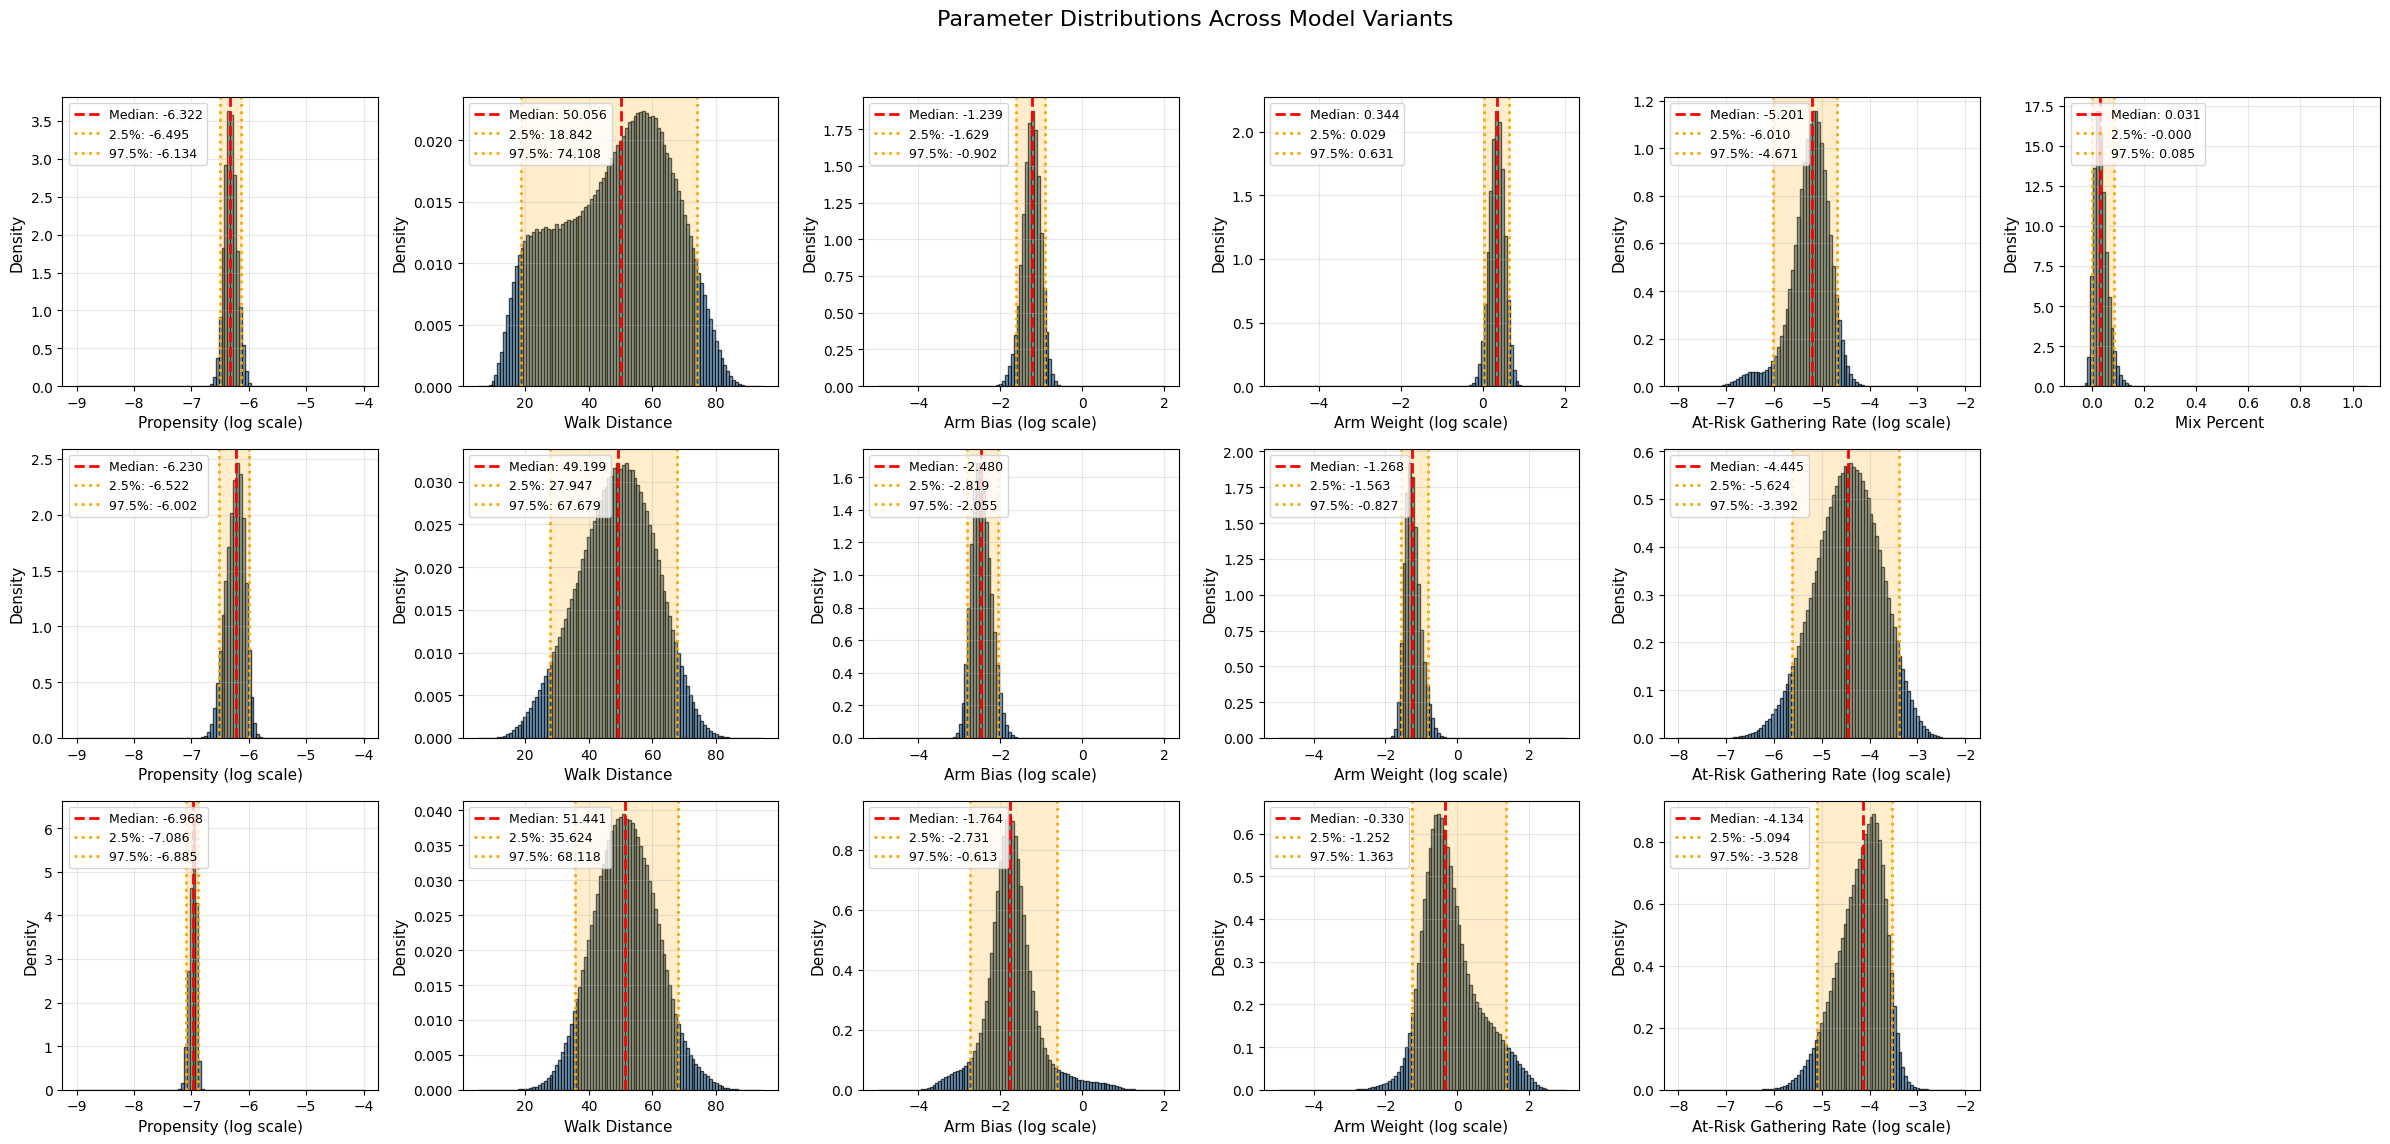

In [7]:
fig, fig_axes = plt.subplots(3, 6, figsize=(24, 12))
for i, vp, param_config in zip(range(len(vp_l)), vp_l, param_configs):
    param_distr = ParamDistr(param_config)
    range_lower = param_distr.range_lower
    range_upper = param_distr.range_upper
    param_names = param_distr.param_names

    samples, source_gaussian = vp.sample(int(1e6))
    samples = param_distr.expand_range(samples)  # convert from [0,1] to actual parameter ranges
    axes = fig_axes[i].flatten()
    # Calculate statistics for each parameter
    n_params = samples.shape[1]
    medians = np.median(samples, axis=0)
    ci_lower = np.percentile(samples, 5, axis=0)  # 2.5th percentile
    ci_upper = np.percentile(samples, 95, axis=0)  # 97.5th percentile

    for i in range(n_params):
        ax = axes[i]
        param_samples = samples[:, i]

        # Plot histogram
        ax.hist(param_samples, bins=np.linspace(range_lower[i], range_upper[i], 100), alpha=0.7, color='steelblue', edgecolor='black', density=True)
        
        # Add vertical lines for median and CI
        ax.axvline(medians[i], color='red', linestyle='--', linewidth=2, label=f'Median: {medians[i]:.3f}')
        ax.axvline(ci_lower[i], color='orange', linestyle=':', linewidth=2, label=f'2.5%: {ci_lower[i]:.3f}')
        ax.axvline(ci_upper[i], color='orange', linestyle=':', linewidth=2, label=f'97.5%: {ci_upper[i]:.3f}')
        
        # Add shaded region for 95% CI
        ax.axvspan(ci_lower[i], ci_upper[i], alpha=0.2, color='orange')
        param_label = f"{param_label_map[param_distr.param_names[i]]} {'(log scale)' if param_distr.logscale[i] else ''}"
        ax.set_xlabel(param_label, fontsize=11)
        
        ax.set_ylabel('Density', fontsize=11)
        # ax.set_title(f'{param_distr.param_names[i]} Distribution', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)

    # Remove extra subplot if there are only 5 parameters
    if n_params < 6:
        fig.delaxes(axes[5])
plt.suptitle('Parameter Distributions Across Model Variants', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/home/andrew/abm_violence/paper_code/images/multimodel_parameter_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# plt.tight_layout()
# plt.savefig('/home/andrew/abm_violence/paper_code/images/parameter_distributions.png', dpi=300, bbox_inches='tight')
# plt.show()

In [5]:
from ref import param_label_map

import matplotlib.pyplot as plt
import numpy as np
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config, big_param_config
# param_distr = ParamDistr(param_config)
param_distr = ParamDistr(param_config)
param_names = param_distr.param_names
range_lower = param_distr.range_lower
range_upper = param_distr.range_upper

# range_lower = np.where(~param_distr.logscale, np.log(range_lower) / np.log(10), range_lower)
# range_upper = np.where(~param_distr.logscale, np.log(range_upper) / np.log(10), range_upper)

range_lower, range_upper, param_distr.logscale

(Array([-9,  5, -5, -5, -8], dtype=int32),
 Array([-4, 95,  2,  3, -2], dtype=int32),
 Array([ True, False,  True,  True,  True], dtype=bool))

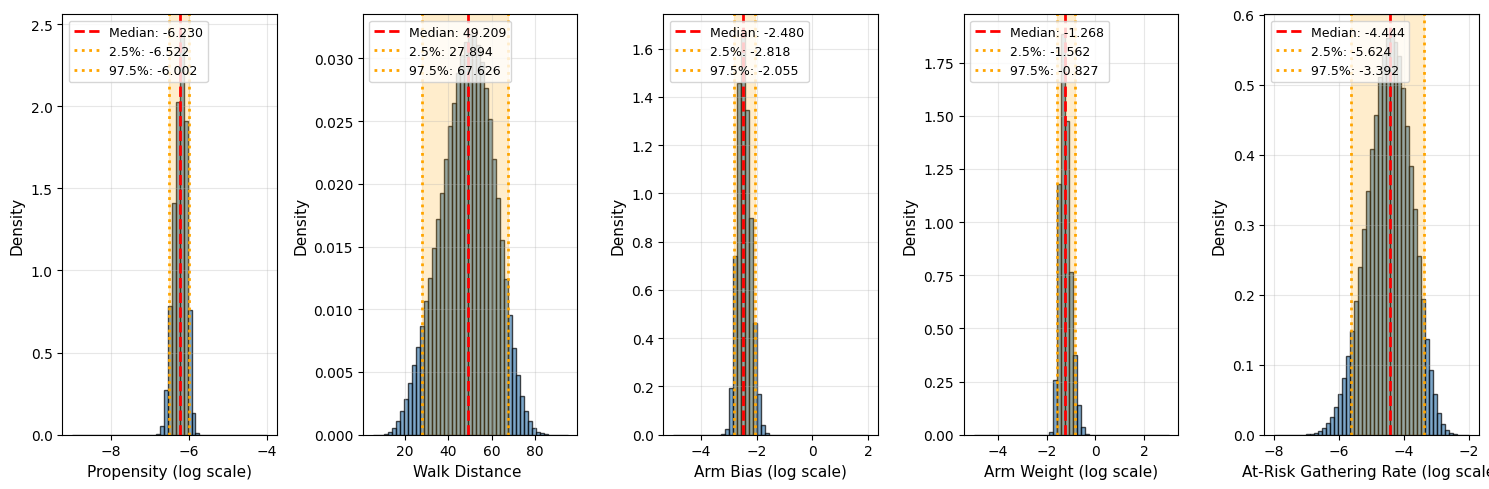

Parameter Summary Statistics:
propensity                | Median:     -6.230 | 95% CI: [    -6.522,     -6.002] | Width:      0.519
walk_radius               | Median:     49.209 | 95% CI: [    27.894,     67.626] | Width:     39.732
arm_bias                  | Median:     -2.480 | 95% CI: [    -2.818,     -2.055] | Width:      0.763
arm_weight                | Median:     -1.268 | 95% CI: [    -1.562,     -0.827] | Width:      0.735
atrisk_gathering_rate     | Median:     -4.444 | 95% CI: [    -5.624,     -3.392] | Width:      2.232


In [7]:
# Sample from the variational posterior
samples, source_gaussian = vp.sample(int(1e6))
samples = param_distr.expand_range(samples)  # convert from [0,1] to actual parameter ranges

# Calculate statistics for each parameter
n_params = samples.shape[1]
medians = np.median(samples, axis=0)
ci_lower = np.percentile(samples, 5, axis=0)  # 2.5th percentile
ci_upper = np.percentile(samples, 95, axis=0)  # 97.5th percentile

# Create subplots for each parameter
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
axes = axes.flatten()

for i in range(n_params):
    ax = axes[i]
    param_samples = samples[:, i]


    # Plot histogram
    ax.hist(param_samples, bins=np.linspace(range_lower[i], range_upper[i], 50), alpha=0.7, color='steelblue', edgecolor='black', density=True)
    
    # Add vertical lines for median and CI
    ax.axvline(medians[i], color='red', linestyle='--', linewidth=2, label=f'Median: {medians[i]:.3f}')
    ax.axvline(ci_lower[i], color='orange', linestyle=':', linewidth=2, label=f'2.5%: {ci_lower[i]:.3f}')
    ax.axvline(ci_upper[i], color='orange', linestyle=':', linewidth=2, label=f'97.5%: {ci_upper[i]:.3f}')
    
    # Add shaded region for 95% CI
    ax.axvspan(ci_lower[i], ci_upper[i], alpha=0.2, color='orange')
    

    param_label = f"{param_label_map[param_distr.param_names[i]]} {'(log scale)' if param_distr.logscale[i] else ''}"
    ax.set_xlabel(param_label, fontsize=11)
    
    ax.set_ylabel('Density', fontsize=11)
    # ax.set_title(f'{param_distr.param_names[i]} Distribution', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplot if there are only 5 parameters
# if n_params < 6:
#     fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/parameter_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Parameter Summary Statistics:")
print("=" * 70)
for i in range(n_params):
    ci_width = ci_upper[i] - ci_lower[i]
    print(f"{param_names[i]:25s} | Median: {medians[i]:10.3f} | 95% CI: [{ci_lower[i]:10.3f}, {ci_upper[i]:10.3f}] | Width: {ci_width:10.3f}")


NameError: name 'walk_radius' is not defined

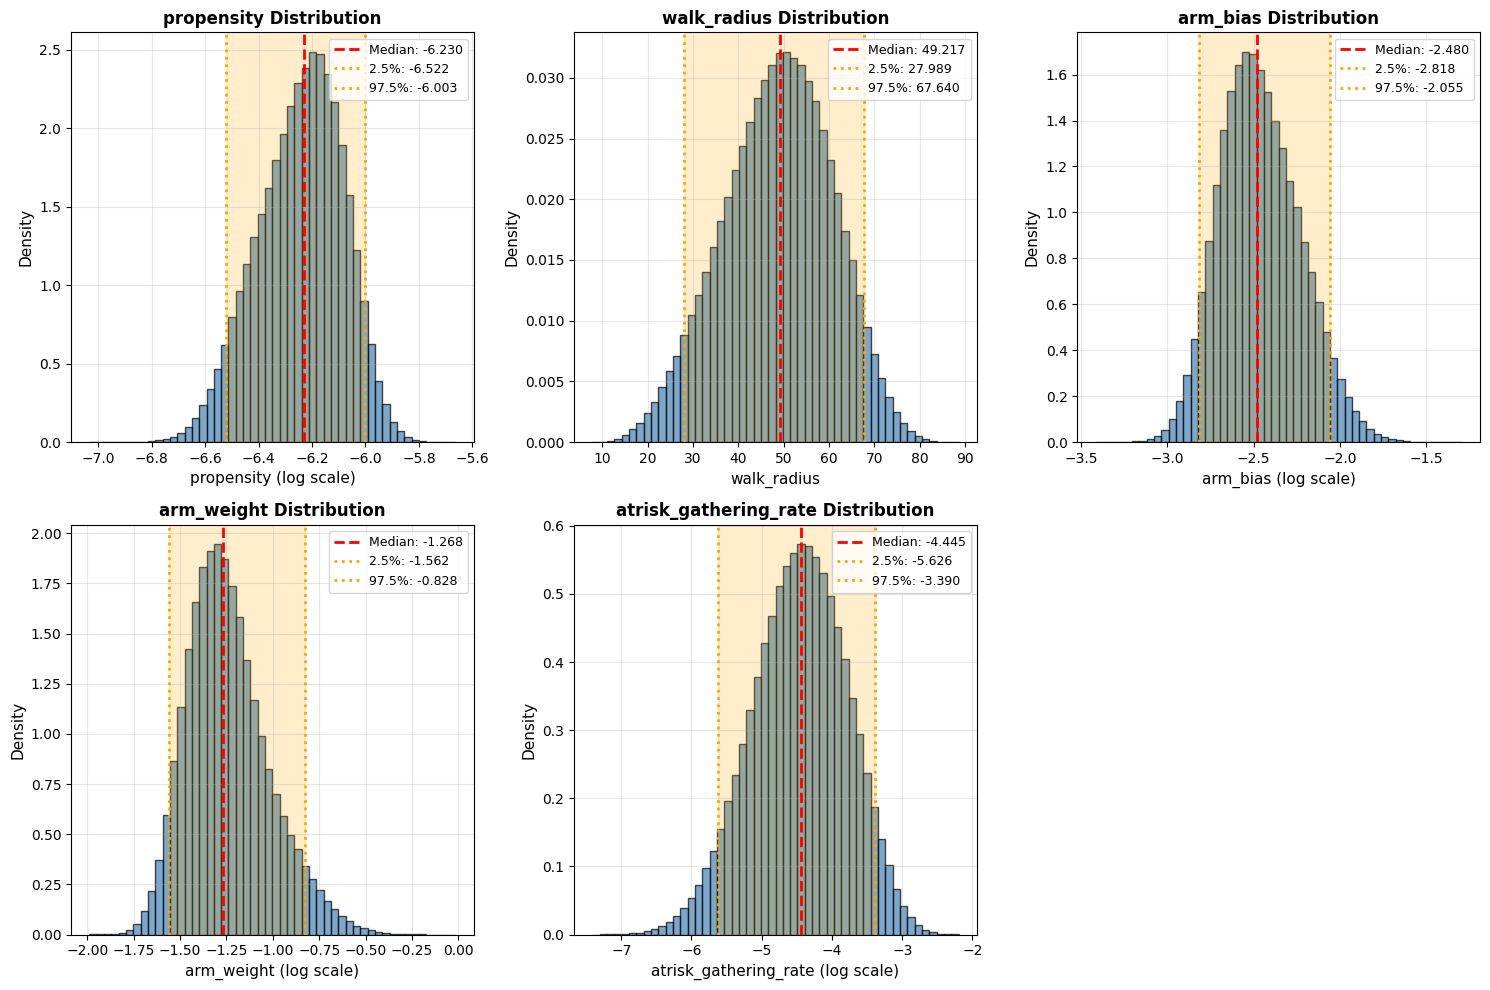

Parameter Summary Statistics:
propensity                | Median:     -6.230 | 95% CI: [    -6.522,     -6.003] | Width:      0.519
walk_radius               | Median:     49.217 | 95% CI: [    27.989,     67.640] | Width:     39.651
arm_bias                  | Median:     -2.480 | 95% CI: [    -2.818,     -2.055] | Width:      0.762
arm_weight                | Median:     -1.268 | 95% CI: [    -1.562,     -0.828] | Width:      0.734
atrisk_gathering_rate     | Median:     -4.445 | 95% CI: [    -5.626,     -3.390] | Width:      2.236


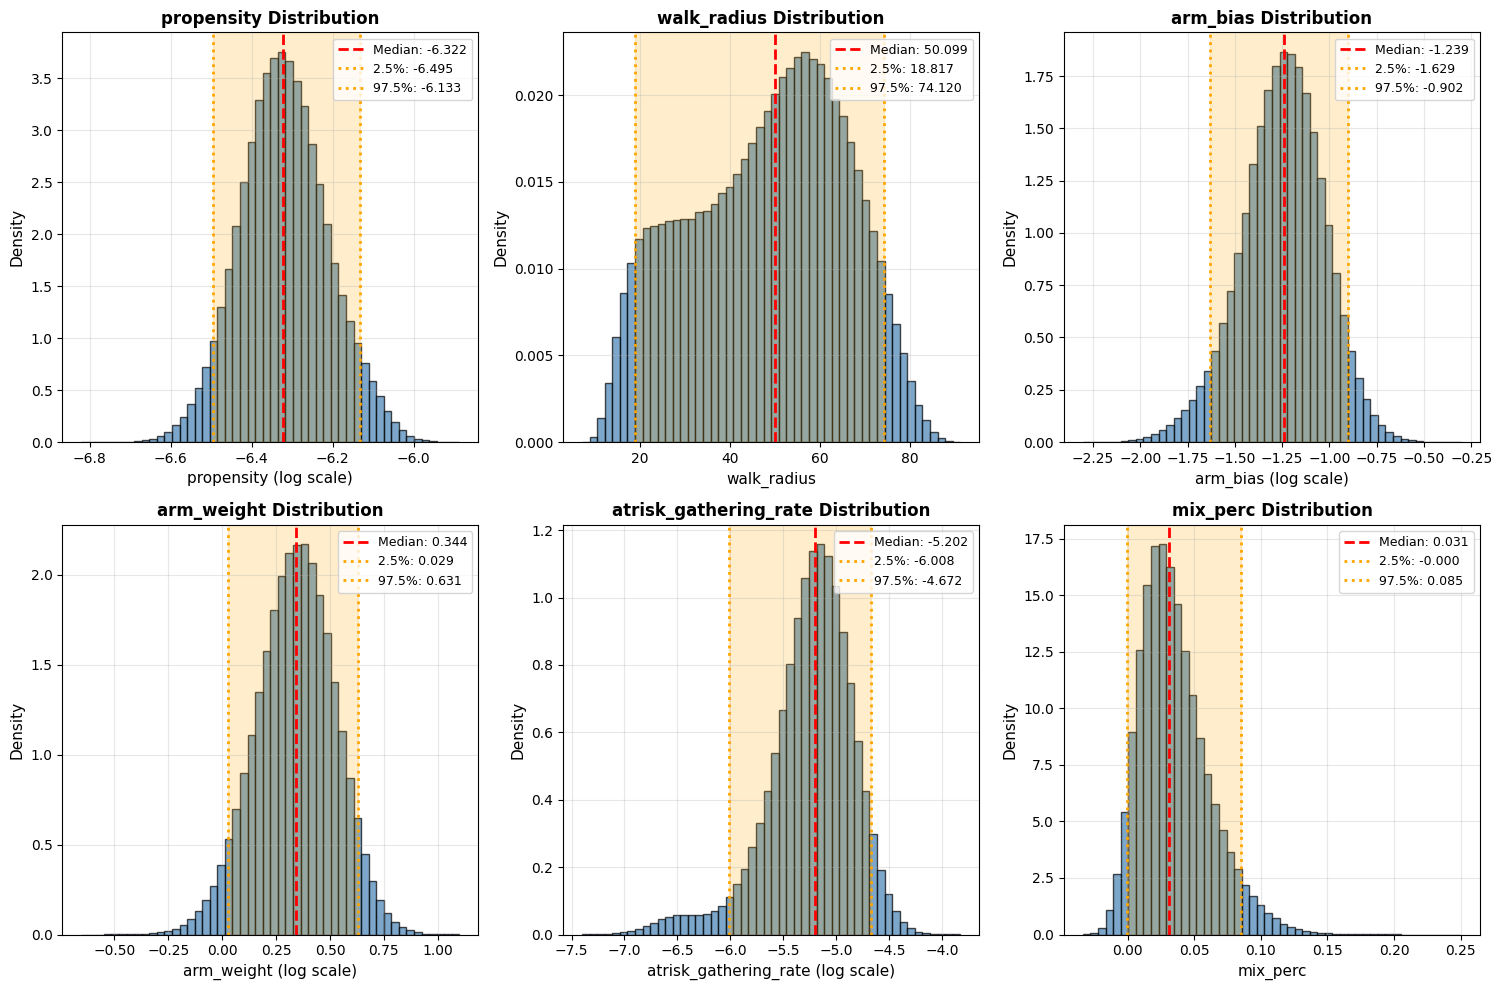

Parameter Summary Statistics:
propensity                | Median:     -6.322 | 95% CI: [    -6.495,     -6.133] | Width:      0.361
walk_radius               | Median:     50.099 | 95% CI: [    18.817,     74.120] | Width:     55.304
arm_bias                  | Median:     -1.239 | 95% CI: [    -1.629,     -0.902] | Width:      0.727
arm_weight                | Median:      0.344 | 95% CI: [     0.029,      0.631] | Width:      0.602
atrisk_gathering_rate     | Median:     -5.202 | 95% CI: [    -6.008,     -4.672] | Width:      1.336
mix_perc                  | Median:      0.031 | 95% CI: [    -0.000,      0.085] | Width:      0.085


In [ ]:
samples, _ = vp.sample(int(2))
general_samples = [param_distr.to_data(param_distr.transform_sample(s)) for s in samples]
print(general_samples)

[MixedGeneralParams(propensity=Array(4.372039e-07, dtype=float32), walk_radius=Array(41.47439, dtype=float32), arm_bias=Array(0.07910125, dtype=float32), arm_weight=Array(2.07533, dtype=float32), atrisk_gathering_rate=Array(3.709693e-06, dtype=float32), mix_perc=Array(0.04462855, dtype=float32)), MixedGeneralParams(propensity=Array(4.0505074e-07, dtype=float32), walk_radius=Array(31.834791, dtype=float32), arm_bias=Array(0.07267632, dtype=float32), arm_weight=Array(3.1772184, dtype=float32), atrisk_gathering_rate=Array(4.0339523e-06, dtype=float32), mix_perc=Array(0.05366912, dtype=float32))]


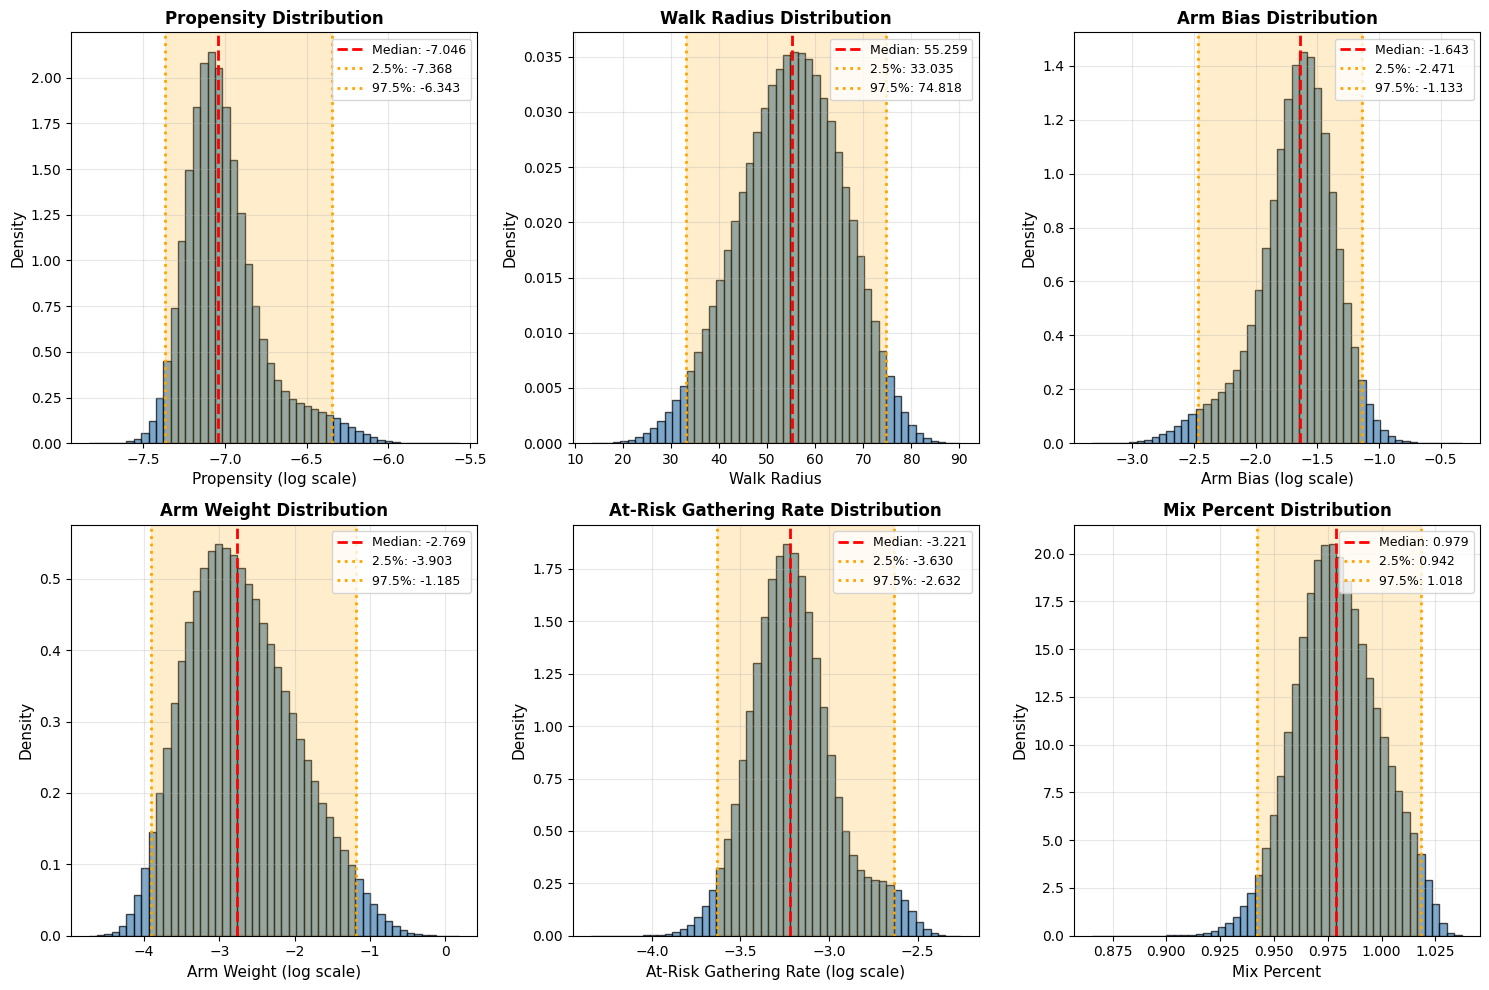

Parameter Summary Statistics:
propensity                | Median:     -7.046 | 95% CI: [    -7.368,     -6.343] | Width:      1.025
walk_radius               | Median:     55.259 | 95% CI: [    33.035,     74.818] | Width:     41.783
arm_bias                  | Median:     -1.643 | 95% CI: [    -2.471,     -1.133] | Width:      1.337
arm_weight                | Median:     -2.769 | 95% CI: [    -3.903,     -1.185] | Width:      2.718
atrisk_gathering_rate     | Median:     -3.221 | 95% CI: [    -3.630,     -2.632] | Width:      0.998
mix_perc                  | Median:      0.979 | 95% CI: [     0.942,      1.018] | Width:      0.076


In [55]:
import matplotlib.pyplot as plt
import numpy as np
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config
# param_distr = ParamDistr(param_config)
param_distr = ParamDistr(mixed_choice_param_config)
param_names = param_distr.param_names

# Sample from the variational posterior
samples, source_gaussian = vp.sample(int(1e6))
samples = param_distr.expand_range(samples)  # convert from [0,1] to actual parameter ranges

# Calculate statistics for each parameter
n_params = samples.shape[1]
medians = np.median(samples, axis=0)
ci_lower = np.percentile(samples, 2.5, axis=0)  # 2.5th percentile
ci_upper = np.percentile(samples, 97.5, axis=0)  # 97.5th percentile

# Create subplots for each parameter
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_params):
    ax = axes[i]
    param_samples = samples[:, i]
    
    # Plot histogram
    ax.hist(param_samples, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
    
    # Add vertical lines for median and CI
    ax.axvline(medians[i], color='red', linestyle='--', linewidth=2, label=f'Median: {medians[i]:.3f}')
    ax.axvline(ci_lower[i], color='orange', linestyle=':', linewidth=2, label=f'2.5%: {ci_lower[i]:.3f}')
    ax.axvline(ci_upper[i], color='orange', linestyle=':', linewidth=2, label=f'97.5%: {ci_upper[i]:.3f}')
    
    # Add shaded region for 95% CI
    ax.axvspan(ci_lower[i], ci_upper[i], alpha=0.2, color='orange')
    
    # Format x-axis based on log scale
    if param_distr.logscale[i]:
        # ax.set_xscale('log')
        ax.set_xlabel(f'{param_names_readable[i]} (log scale)', fontsize=11)
    else:
        ax.set_xlabel(param_names_readable[i], fontsize=11)
    
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{param_names_readable[i]} Distribution', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplot if there are only 5 parameters
if n_params < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/parameter_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Parameter Summary Statistics:")
print("=" * 70)
for i in range(n_params):
    ci_width = ci_upper[i] - ci_lower[i]
    print(f"{param_names[i]:25s} | Median: {medians[i]:10.3f} | 95% CI: [{ci_lower[i]:10.3f}, {ci_upper[i]:10.3f}] | Width: {ci_width:10.3f}")


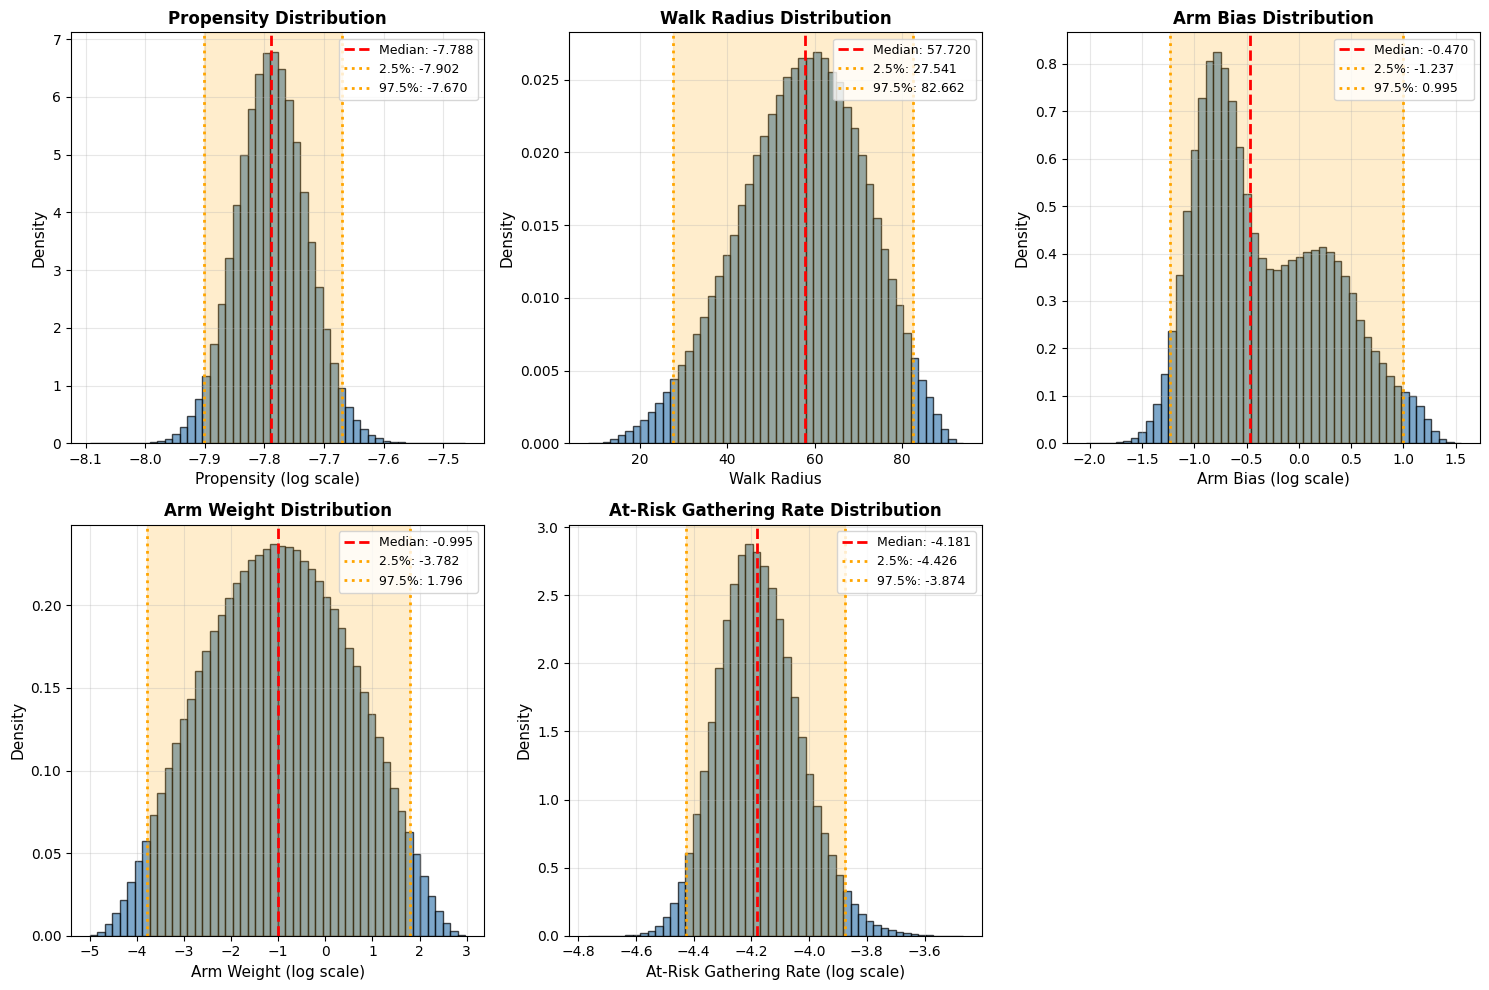

Parameter Summary Statistics:
propensity                | Median:     -7.788 | 95% CI: [    -7.902,     -7.670] | Width:      0.232
walk_radius               | Median:     57.720 | 95% CI: [    27.541,     82.662] | Width:     55.121
arm_bias                  | Median:     -0.470 | 95% CI: [    -1.237,      0.995] | Width:      2.231
arm_weight                | Median:     -0.995 | 95% CI: [    -3.782,      1.796] | Width:      5.578
atrisk_gathering_rate     | Median:     -4.181 | 95% CI: [    -4.426,     -3.874] | Width:      0.552


IndexError: index -1 is out of bounds for axis 0 with size 0

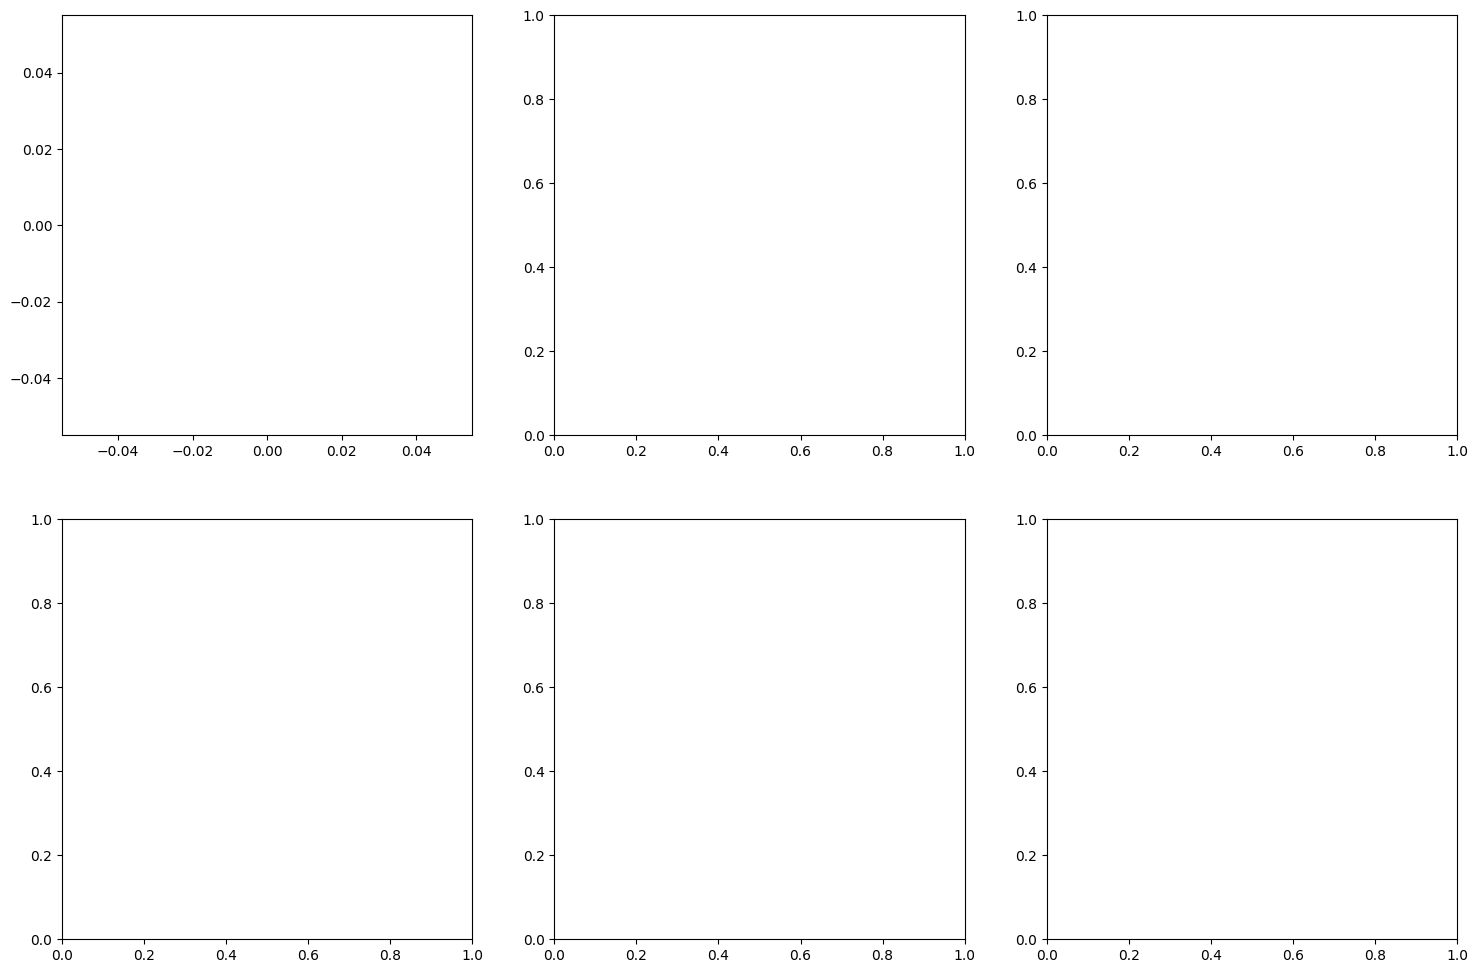

In [6]:
# Plot arm_weight distribution conditional on arm_bias quantiles
import matplotlib.pyplot as plt
import numpy as np

# Get indices for arm_bias and arm_weight
ind1 = param_names.index('arm_bias')
ind2 = param_names.index('arm_weight')

# Define quantiles for arm_bias
quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]
quantile_values = np.percentile(samples[:, ind1], [q * 100 for q in quantiles])

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = plt.cm.viridis(np.linspace(0, 1, len(quantiles)))

# For each quantile, filter samples and plot arm_weight distribution
for idx, (q, q_val, color) in enumerate(zip(quantiles, quantile_values, colors)):
    ax = axes[idx]
    
    # Define window around quantile (±5 percentile points)
    lower_bound = np.percentile(samples[:, ind1], (q * 100) - 5)
    upper_bound = np.percentile(samples[:, ind1], (q * 100) + 5)
    
    # Filter samples where arm_bias is in this range
    mask = (samples[:, ind1] >= lower_bound) & (samples[:, ind1] <= upper_bound)
    conditional_arm_weight = samples[mask, ind2]
    
    # Plot histogram
    ax.hist(conditional_arm_weight, bins=50, alpha=0.7, color=color, edgecolor='black', density=True)
    
    # Calculate statistics for this conditional distribution
    cond_median = np.median(conditional_arm_weight)
    cond_ci_lower = np.percentile(conditional_arm_weight, 2.5)
    cond_ci_upper = np.percentile(conditional_arm_weight, 97.5)
    
    # Add vertical lines
    ax.axvline(cond_median, color='red', linestyle='--', linewidth=2, label=f'Median: {cond_median:.3f}')
    ax.axvline(cond_ci_lower, color='orange', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(cond_ci_upper, color='orange', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(cond_ci_lower, cond_ci_upper, alpha=0.2, color='orange', label=f'95% CI')
    
    ax.set_xlabel('Arm Weight', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Arm Weight | Arm Bias at {q*100:.0f}th percentile\n(Arm Bias ≈ {q_val:.3f}, n={mask.sum():,})', 
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/arm_weight_conditional_on_arm_bias.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nConditional Distribution Summary:")
print("=" * 80)
print(f"{'Arm Bias Quantile':<20} | {'Arm Bias Value':<15} | {'Arm Weight Median':<18} | {'95% CI':<25}")
print("-" * 80)
for q, q_val in zip(quantiles, quantile_values):
    lower_bound = np.percentile(samples[:, ind1], (q * 100) - 5)
    upper_bound = np.percentile(samples[:, ind1], (q * 100) + 5)
    mask = (samples[:, ind1] >= lower_bound) & (samples[:, ind1] <= upper_bound)
    conditional_arm_weight = samples[mask, ind2]
    
    cond_median = np.median(conditional_arm_weight)
    cond_ci_lower = np.percentile(conditional_arm_weight, 2.5)
    cond_ci_upper = np.percentile(conditional_arm_weight, 97.5)
    
    print(f"{q*100:>6.0f}th percentile    | {q_val:>14.3f} | {cond_median:>17.3f} | [{cond_ci_lower:.3f}, {cond_ci_upper:.3f}]")


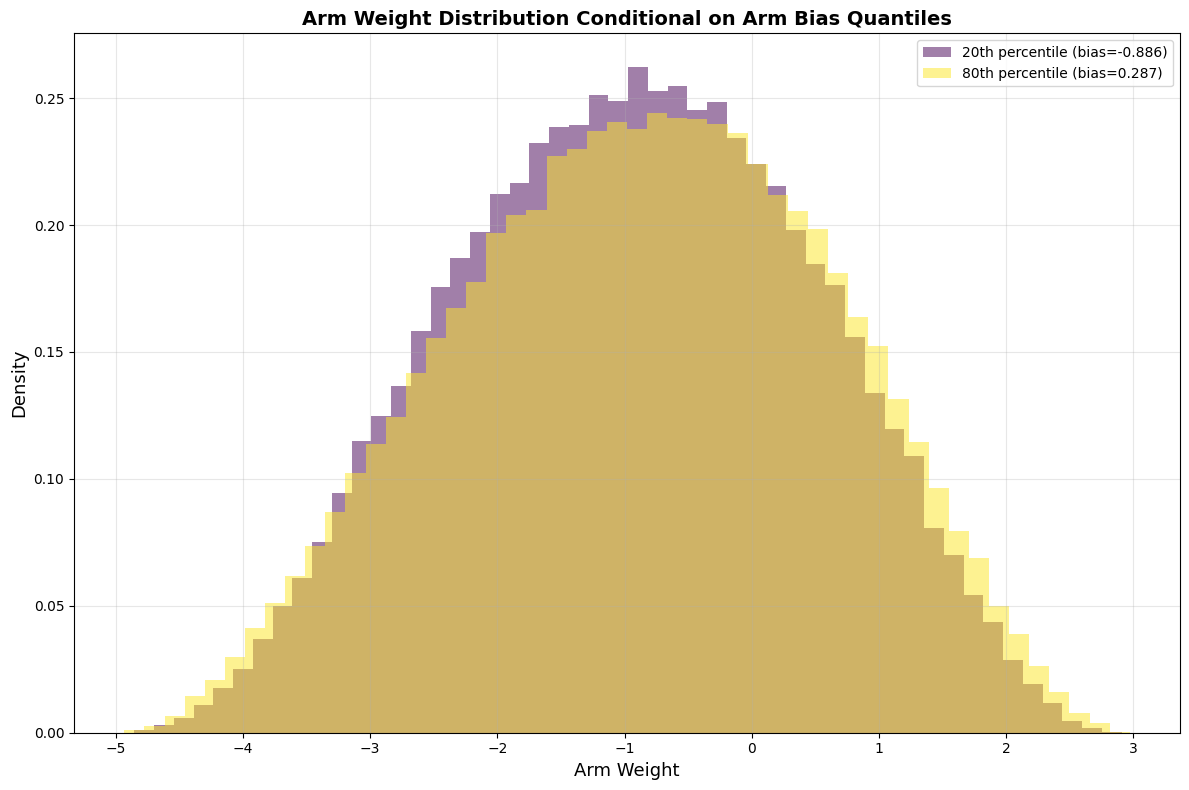

In [39]:
# Alternative visualization: Overlay all conditional distributions
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

quantiles = [0.2, 0.8]
quantile_values = np.percentile(samples[:, arm_bias_idx], [q * 100 for q in quantiles])
colors = plt.cm.viridis(np.linspace(0, 1, len(quantiles)))

for q, q_val, color in zip(quantiles, quantile_values, colors):
    # Define window around quantile
    lower_bound = np.percentile(samples[:, arm_bias_idx], (q * 100) - 5)
    upper_bound = np.percentile(samples[:, arm_bias_idx], (q * 100) + 5)
    
    # Filter samples
    mask = (samples[:, arm_bias_idx] >= lower_bound) & (samples[:, arm_bias_idx] <= upper_bound)
    conditional_arm_weight = samples[mask, arm_weight_idx]
    
    # Plot KDE or histogram
    counts, bins, _ = ax.hist(conditional_arm_weight, bins=50, alpha=0.5, color=color, 
                              density=True, label=f'{q*100:.0f}th percentile (bias={q_val:.3f})')

ax.set_xlabel('Arm Weight', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Arm Weight Distribution Conditional on Arm Bias Quantiles', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/arm_weight_conditional_overlay.png', 
            dpi=300, bbox_inches='tight')
plt.show()


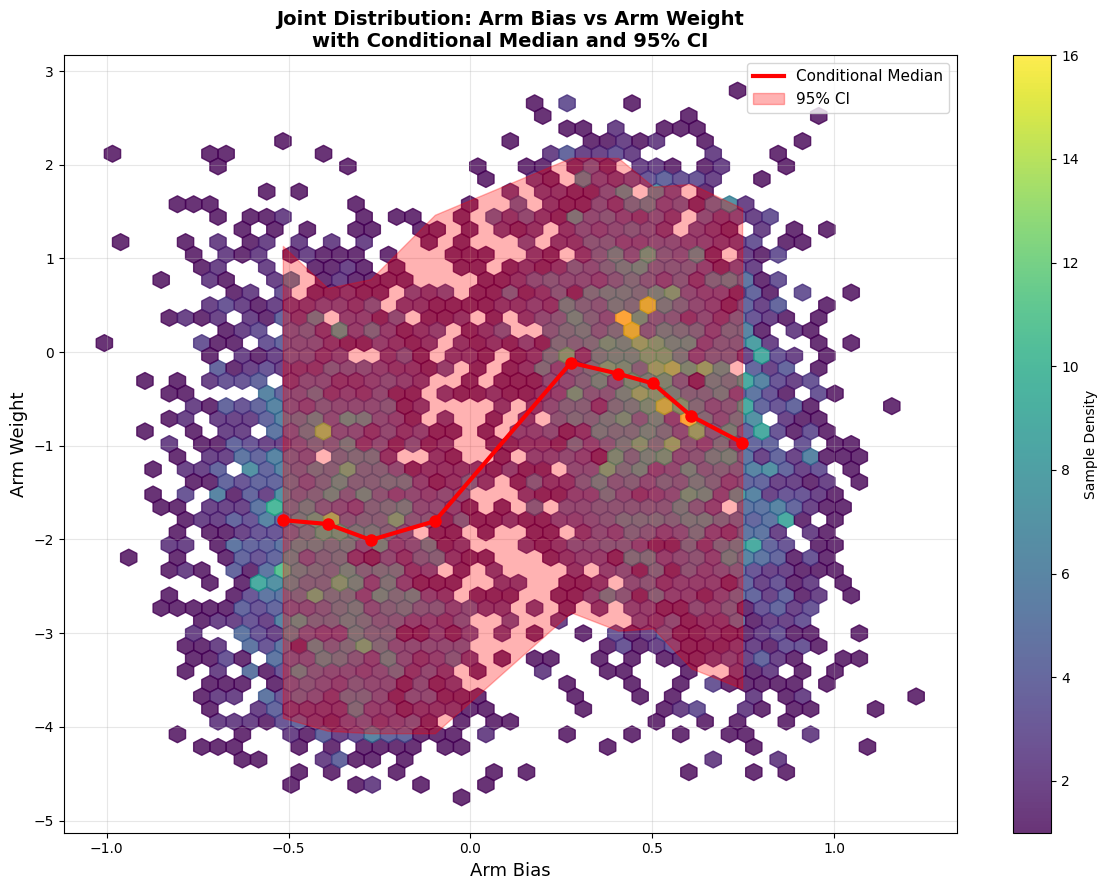


Correlation between Arm Bias and Arm Weight: 0.2756


In [45]:
# 2D visualization: Joint distribution with conditional medians
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

mid_walk_samples = samples[(samples[:, param_names.index('walk_radius')] < 20) & 
                           (samples[:, param_names.index('walk_radius')] < 120)]

# Create 2D histogram/heatmap
h = ax.hexbin(mid_walk_samples[:, arm_bias_idx], mid_walk_samples[:, arm_weight_idx], 
              gridsize=50, cmap='viridis', mincnt=1, alpha=0.8)
plt.colorbar(h, ax=ax, label='Sample Density')

# Overlay conditional medians and confidence intervals
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
quantile_values = np.percentile(mid_walk_samples[:, arm_bias_idx], [q * 100 for q in quantiles])

medians = []
ci_lowers = []
ci_uppers = []

for q, q_val in zip(quantiles, quantile_values):
    lower_bound = np.percentile(mid_walk_samples[:, arm_bias_idx], (q * 100) - 5)
    upper_bound = np.percentile(mid_walk_samples[:, arm_bias_idx], (q * 100) + 5)
    mask = (mid_walk_samples[:, arm_bias_idx] >= lower_bound) & (mid_walk_samples[:, arm_bias_idx] <= upper_bound)
    conditional_arm_weight = mid_walk_samples[mask, arm_weight_idx]

    medians.append(np.median(conditional_arm_weight))
    ci_lowers.append(np.percentile(conditional_arm_weight, 2.5))
    ci_uppers.append(np.percentile(conditional_arm_weight, 97.5))

# Plot median line
ax.plot(quantile_values, medians, 'r-', linewidth=3, label='Conditional Median', zorder=10)
ax.plot(quantile_values, medians, 'ro', markersize=8, zorder=11)

# Plot confidence band
ax.fill_between(quantile_values, ci_lowers, ci_uppers, alpha=0.3, color='red', 
                label='95% CI', zorder=9)

ax.set_xlabel('Arm Bias', fontsize=13)
ax.set_ylabel('Arm Weight', fontsize=13)
ax.set_title('Joint Distribution: Arm Bias vs Arm Weight\nwith Conditional Median and 95% CI', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/arm_weight_arm_bias_joint.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Calculate correlation
correlation = np.corrcoef(mid_walk_samples[:, arm_bias_idx], mid_walk_samples[:, arm_weight_idx])[0, 1]
print(f"\nCorrelation between Arm Bias and Arm Weight: {correlation:.4f}")
